Project: Predict House Price 🏠

Goal: Predict house price using house size and number of bedrooms.m

In [3]:
# Import pandas for working with tabular data
import pandas as pd
# Import matplotlib for visualization
import matplotlib.pyplot as plt
# Import train_test_split to divide data
from sklearn.model_selection import train_test_split
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler
# Import KNN Regression model
from sklearn.neighbors import KNeighborsRegressor
# Import regression evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
# Create a small house-price dataset
# Area is measured in square feet
# Bedrooms = number of bedrooms
# Price is measured in lakh rupees
data = {
    "Area": [800, 900, 1000, 1100, 1200, 1300, 1400, 1500,
             1600, 1700, 1800, 1900, 2000, 2100, 2200],

    "Bedrooms": [2, 2, 2, 2, 3, 3, 3, 3,
                 3, 4, 4, 4, 4, 4, 5],

    "Price": [35, 38, 42, 45, 50, 54, 58, 62,
              67, 72, 78, 83, 88, 94, 100]
}
# Convert dictionary into DataFrame
df = pd.DataFrame(data)
# Display the dataset
df.head(4)

,Area,Bedrooms,Price
0,800,2,35
1,900,2,38
2,1000,2,42
3,1100,2,45


In [14]:
print("-----Display information about columns and data types---")
df.info()
print("------------")

print("--------Check the number of missing values in each column-")
df.isnull().sum()


-----Display information about columns and data types---
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Area      15 non-null     int64
 1   Bedrooms  15 non-null     int64
 2   Price     15 non-null     int64
dtypes: int64(3)
memory usage: 492.0 bytes
------------
--------Check the number of missing values in each column-


Area        0
Bedrooms    0
Price       0
dtype: int64

In [13]:
print("------Display basic statistical information------")
df.describe()

------Display basic statistical information------


,Area,Bedrooms,Price
count,15.000000,15.000000,15.000000
mean,1500.000000,3.200000,64.400000
std,447.213595,0.941124,20.869664
min,800.000000,2.000000,35.000000
25%,1150.000000,2.500000,47.500000
50%,1500.000000,3.000000,62.000000
75%,1850.000000,4.000000,80.500000
max,2200.000000,5.000000,100.000000


In [15]:
# X contains the input features
X = df[["Area", "Bedrooms"]]

# y contains the value we want to predict
y = df["Price"]

print("Features:")
print(X)

print("\nTarget:")
print(y)

Features:
    Area  Bedrooms
0    800         2
1    900         2
2   1000         2
3   1100         2
4   1200         3
5   1300         3
6   1400         3
7   1500         3
8   1600         3
9   1700         4
10  1800         4
11  1900         4
12  2000         4
13  2100         4
14  2200         5

Target:
0      35
1      38
2      42
3      45
4      50
5      54
6      58
7      62
8      67
9      72
10     78
11     83
12     88
13     94
14    100
Name: Price, dtype: int64


In [17]:
# Split the dataset into training and testing data
# 80% → training
# 20% → testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 12
Testing samples: 3


In [18]:
# Create StandardScaler
scaler = StandardScaler()

# Learn scaling parameters from training data
# and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaling parameters on test data
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Data:")
print(X_train_scaled)

print("\nScaled Testing Data:")
print(X_test_scaled)

Scaled Training Data:
[[ 1.41127704  0.92847669]
 [-0.49692854 -0.18569534]
 [ 0.21864856 -0.18569534]
 [-1.21250563 -1.29986737]
 [-1.45103132 -1.29986737]
 [ 1.64980274  2.04264872]
 [-0.73545423 -0.18569534]
 [-0.01987714 -0.18569534]
 [ 0.69569995  0.92847669]
 [ 1.17275134  0.92847669]
 [-0.97397993 -1.29986737]
 [-0.25840284 -0.18569534]]

Scaled Testing Data:
[[ 0.45717425  0.92847669]
 [ 0.93422565  0.92847669]
 [-1.68955702 -1.29986737]]


In [20]:
# Create the KNN Regression model
# K = 3 means the model considers 3 nearest houses

model = KNeighborsRegressor(n_neighbors=3)

print(model)

KNeighborsRegressor(n_neighbors=3)


In [21]:
# Train the KNN Regression model
model.fit(X_train_scaled, y_train)

print("KNN Regression model trained successfully!")

KNN Regression model trained successfully!


In [22]:
# Predict prices for the test data
y_pred = model.predict(X_test_scaled)

# Display predictions
print("Predicted Prices:")
print(y_pred)

Predicted Prices:
[86.66666667 86.66666667 41.66666667]


In [23]:
# Create a comparison DataFrame
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

# Display comparison
comparison

,Actual Price,Predicted Price
0,72,86.666667
1,83,86.666667
2,35,41.666667


In [24]:
# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 8.333333333333336


In [25]:
# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 91.00000000000006


In [26]:
# Calculate RMSE
# RMSE is the square root of MSE

rmse = mse ** 0.5

print("RMSE:", rmse)

RMSE: 9.53939201416946


In [27]:
# Calculate R-squared
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.7841328413284132


In [29]:
# Display all evaluation metrics together

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")

MAE  : 8.33
MSE  : 91.00
RMSE : 9.54
R²   : 0.78


In [30]:
#Area = 1550 sq ft  Bedrooms = 3
# Create data for a new house
new_house = [[1550, 3]]

# Scale the new house using the already-fitted scaler
new_house_scaled = scaler.transform(new_house)

# Predict its price
new_price = model.predict(new_house_scaled)

print(f"Predicted House Price: {new_price[0]:.2f} lakh")

Predicted House Price: 62.33 lakh


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


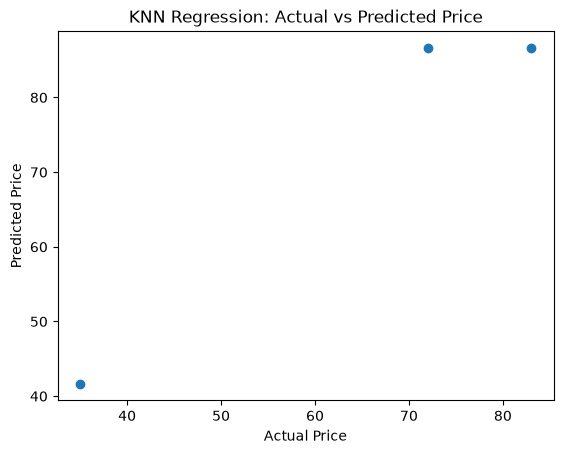

In [31]:
# Plot actual and predicted prices

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("KNN Regression: Actual vs Predicted Price")

plt.show()